### 第9章 图像梯度
- 一般情况下，图像梯度计算的是图像的边缘信息。严格来讲，图像梯度需要计算导数，但一般可通过计算像素值的差来得到梯度的近似值。
- 使用不同的卷积核能够实现不同的效果
    - 平滑：$ k = \dfrac{1}{9} \begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix} $ 使用邻域像素均值替换当前像素点的值
    - 复制：$ k = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 0 \end{bmatrix} $ 当前像素点权重为1，周围邻域像素点权重均为0
    - 锐化：$ k = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix} $ 当前像素点值的5倍减去周围像素点的值
    - 边缘：$ k = \begin{bmatrix} -1 & -1 & -1 \\ -1 & 8 & -1 \\ -1 & -1 & -1 \end{bmatrix} $ 当前像素点值的8倍减去邻域内其他像素点的值

#### 9.1 Sobel算子
- 滤波器通常是指由一幅图像的像素点(x, y)临近的区域计算得到另外一幅图像的算法
- 滤波器也被称为“核”、“模板”、“窗口”、“算子”、“掩膜（掩码）”等，这里用“算子”表示卷积运算所使用的滤波器
- Sobel 算子是一种离散的微分算子，结合了高斯平滑核微分求导运算。该算子利用局部差分寻找边缘，得到的是梯度的近似值。
- 计算水平方向偏导数的近似值：
$$ \Delta_{x} = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \ast \mathrm{src} $$
- 计算垂直方向偏导数的近似值：
$$ \Delta_{y} = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} \ast \mathrm{src} $$

- `dst = cv2.Sobel(src, ddepth, dx, dy[, ksize[, scale[, delta[, borderType]]]])`
    - dst 代表目标图像；src 代表原始图像
    - ddepth 表示输出图像的深度
    - dx 代表x方向上的求导阶数；dy 代表y方向上的求导阶数
    - ksize 代表 Sobel 核的大小，值必须是1、3、5或者7
    - scale 表示计算导数时所的缩放因子，默认为1，无缩放
    - delta 表示加到目标图像上的亮度值，默认为0
    - borderType 代表边界样式


- 在实际操作中，计算梯度值可能出现负数。通常处理的图像是8位图，如果结果也是该类型，那么所有负数会自动截断为0，发生信息丢失。所以在计算时使用更高的数据类型`cv2.CV_64F`，再通过取绝对值将其映射为`cv2.CV_8U`类型。上述过程可描述为“将所有的值先取绝对值，然后再将所有超过255的值截断为255”。
    - `dst = cv2.covertScaleAbs(src[, alpha[, beta]])`, 其中
        - dst 代表处理结果；src 代表原始图像
        - alpha 代表调节系数，默认为1
        - beta 代表亮度值， 默认为0
$$ \mathrm{dst} = \mathrm{saturate}\left(\left|\mathrm{src} \ast \mathrm{alpha} + \mathrm{beta}\right|\right)
$$

- 参数 dx 和参数 dy 可以有多种形式的组合，主要包括：
    - 计算 x 方向梯度：dx = 1, dy = 0
    - 计算 y 方向梯度：dx = 0, dy = 1
    - 参数 dx 与参数 dy 的值均为1：dx = 1, dy = 1
    - 计算 x 方向和 y 方向的边缘叠加：通过组合方式实现

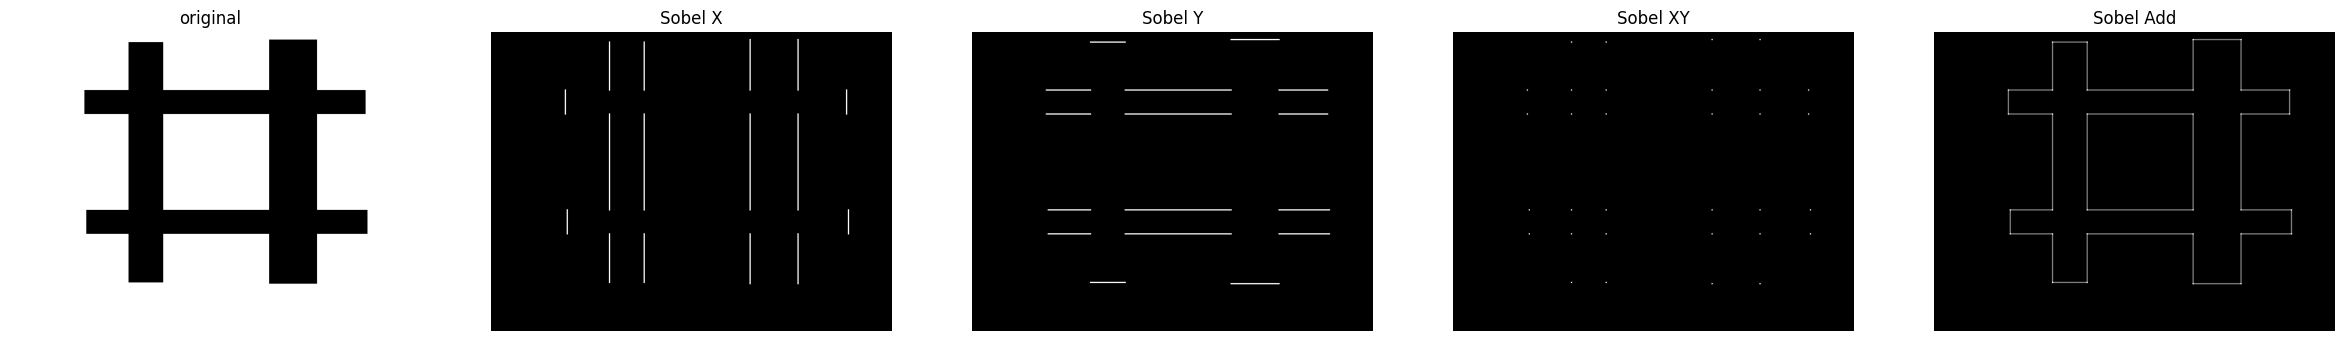

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
o = cv2.imread('sobel4.bmp', cv2.IMREAD_GRAYSCALE)
sobelx = cv2.Sobel(o, cv2.CV_64F, 1, 0)     # x方向求梯度
sobelx = cv2.convertScaleAbs(sobelx)        # 转回uint8  
sobely = cv2.Sobel(o, cv2.CV_64F, 0, 1)     # y方向求梯度
sobely = cv2.convertScaleAbs(sobely) 
sobelxy = cv2.Sobel(o, cv2.CV_64F, 1, 1)    # xy方向求梯度
sobelxy = cv2.convertScaleAbs(sobelxy)  
sobeladd = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0) # x和y方向的梯度图像加权相加

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
sobelx = cv2.cvtColor(sobelx, cv2.COLOR_BGR2RGB)
sobely = cv2.cvtColor(sobely, cv2.COLOR_BGR2RGB)
sobelxy = cv2.cvtColor(sobelxy, cv2.COLOR_BGR2RGB)
sobeladd = cv2.cvtColor(sobeladd, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 6))
plt.subplot(151)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(152)
plt.imshow(sobelx)
plt.title("Sobel X")
plt.axis("off")
plt.subplot(153)
plt.imshow(sobely)
plt.title("Sobel Y")
plt.axis("off")
plt.subplot(154)
plt.imshow(sobelxy)
plt.title("Sobel XY")
plt.axis("off")
plt.subplot(155)
plt.imshow(sobeladd)
plt.title("Sobel Add")
plt.axis("off")
plt.show()
  

#### 9.2 Scharr算子
- OpenCV 提供了 Scharr 算子，具有和 Sobel 算子相同的速度，但精度更高，可以看作是对 Sobel 算子的改进，其核通常为：
$$ G_{x} = \begin{bmatrix} -3 & 0 & 3 \\ -10 & 0 & 10 \\ -3 & 0 & 3 \end{bmatrix} $$
- 计算垂直方向偏导数的近似值：
$$ G_{y} = \begin{bmatrix} -3 & -10 & -3 \\ 0 & 0 & 0 \\ 3 & 10 & 3 \end{bmatrix} $$

- `dst = cv2.Scharr(src, ddepth, dx, dy[, scale[, delta[, borderType]]])`, 其中
    - dst 代表目标图像；src 代表原始图像
    - ddepth 表示输出图像的深度
    - dx 代表x方向上的求导阶数, dy 代表y方向上的求导阶数, dx 和 dy 的值不能都为 1
    - scale 表示计算导数时所的缩放因子，默认为1，无缩放
    - delta 表示加到目标图像上的亮度值，默认为0
    - borderType 代表边界样式
- 在`dst=cv2.Sobel()`中，如果`ksize=-1`，则会使用 Scharr 滤波器，即
    - `dst=cv2.Scharr(src, ddepth, dx, dy)` $ \iff $ `dst=cv2.Sobel(src, ddepth, dx, dy, -1)`

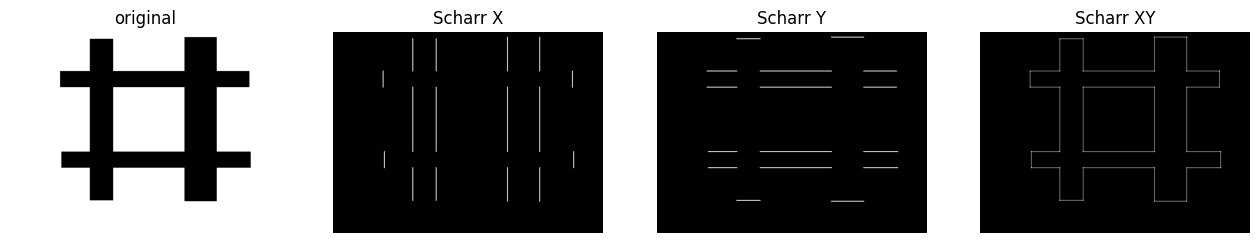

In [11]:
import cv2
o = cv2.imread('scharr.bmp', cv2.IMREAD_GRAYSCALE)
scharrx = cv2.Sobel(o, cv2.CV_64F, 1, 0)     # x方向求梯度
scharrx = cv2.convertScaleAbs(scharrx)        # 转回uint8  
scharry = cv2.Sobel(o, cv2.CV_64F, 0, 1)     # y方向求梯度
scharry = cv2.convertScaleAbs(scharry) 
scharrxy = cv2.addWeighted(scharrx, 0.5, scharry, 0.5, 0) # x和y方向的梯度图像加权相加

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
scharrx = cv2.cvtColor(scharrx, cv2.COLOR_BGR2RGB)
scharry = cv2.cvtColor(scharry, cv2.COLOR_BGR2RGB)
scharrxy = cv2.cvtColor(scharrxy, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 6))
plt.subplot(141)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(142)
plt.imshow(scharrx)
plt.title("Scharr X")
plt.axis("off")
plt.subplot(143)
plt.imshow(scharry)
plt.title("Scharr Y")
plt.axis("off")
plt.subplot(144)
plt.imshow(scharrxy)
plt.title("Scharr XY")
plt.axis("off")
plt.show()
  

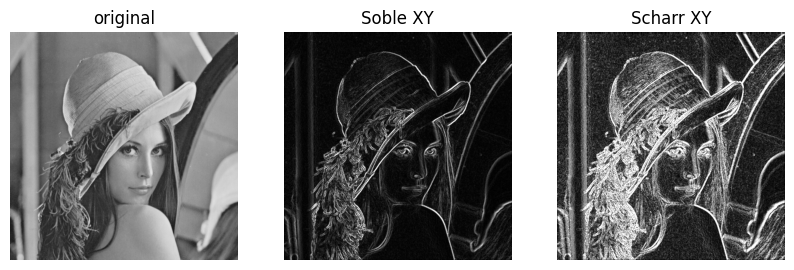

In [14]:
# Sobel 算子和 Scharr 算子的比较
import cv2
o = cv2.imread('lena.bmp', cv2.IMREAD_GRAYSCALE)
sobelx = cv2.Sobel(o,cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(o,cv2.CV_64F, 0, 1, ksize=3)
sobelx = cv2.convertScaleAbs(sobelx)   # 转回uint8  
sobely = cv2.convertScaleAbs(sobely)  
sobelxy = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0) 
scharrx = cv2.Scharr(o, cv2.CV_64F, 1, 0)
scharry = cv2.Scharr(o, cv2.CV_64F, 0, 1)
scharrx = cv2.convertScaleAbs(scharrx)   # 转回uint8  
scharry = cv2.convertScaleAbs(scharry)  
scharrxy = cv2.addWeighted(scharrx, 0.5, scharry, 0.5, 0) 

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
sobelxy = cv2.cvtColor(sobelxy, cv2.COLOR_BGR2RGB)
scharrxy = cv2.cvtColor(scharrxy, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(131)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(132)
plt.imshow(sobelxy)
plt.title("Soble XY")
plt.axis("off")
plt.subplot(133)
plt.imshow(scharrxy)
plt.title("Scharr XY")
plt.axis("off")
plt.show()

#### 9.3 Laplacian 算子
- Laplacian (拉普拉斯) 算子是二阶导数算子，具有旋转不变性，可以满足不同方向的图像边缘锐化（边缘检测）的要求。通常要求算子的系数之和为零
$$
    L = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}
$$
- 由于计算结果可能为正数，也可能为负数，所以需要对计算结果取绝对值，保证后续运算的正确性
- `dst = cv2.Laplacian(src, ddepth, ksize[, scale, delta[, borderType]]]])`, 其中
    - dst 代表目标图像；src 代表原始图像
    - ddepth 表示输出图像的深度
    - ksize 是用于计算二阶导数的核的尺寸大小，值必须是正奇数
    - scale 代表计算Laplacian的缩放比例因子，默认为1，无缩放
    - delta 表示加到目标图像上的可选值，默认为0
    - borderType 代表边界样式
- 当 ksize 的值为 1 时， Laplacian算子的核如上所示；当 ksize 的值大于 1 时，该函数分别对x、y方向进行二次求导，即
$$ \mathrm{dst} = \Delta\mathrm{src} = \frac{\partial^2 \mathrm{src}}{\partial x^2} + \frac{\partial^2 \mathrm{src}}{\partial y^2} $$

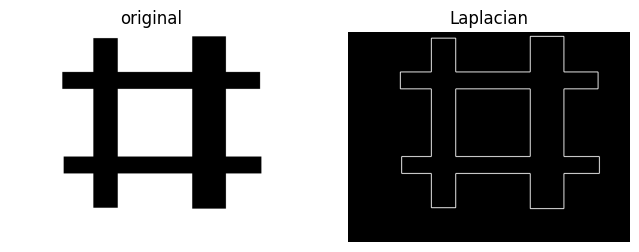

In [16]:
import cv2
o = cv2.imread('Laplacian.bmp', cv2.IMREAD_GRAYSCALE)
Laplacian = cv2.Laplacian(o, cv2.CV_64F)
Laplacian = cv2.convertScaleAbs(Laplacian) 

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
Laplacian = cv2.cvtColor(Laplacian, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(o)
plt.title("original")
plt.axis("off")
plt.subplot(122)
plt.imshow(Laplacian)
plt.title("Laplacian")
plt.axis("off")
plt.show()  


#### 总结
- Sobel 和 Scharr 算子计算的都是一阶近似导数，通常可以表示为
$$ \mathrm{Sobel 算子} = \mathrm{Scharr 算子} = \left|右 - 左\right| \mathrm{or} \left|下 - 上\right| $$
- Laplacian 算子计算的是二阶近似导数，通常可以表示为
$$ \mathrm{Laplacian 算子} = \left|左 - 右\right| + \left|右 - 左\right| + \left|上 - 下\right| + \left|下 - 上\right|$$
